<div style='background:#8B0000; padding:20px; border-radius:8px; margin-bottom:10px'>
<h1 style='color:white; text-align:center; margin:0'>Reconocimiento de Patrones</h1>
<h2 style='color:#ffcccc; text-align:center; margin:5px 0 0 0'>Challenge 3 — Overfitting, Regularización y SVM</h2>
<p style='color:#ffaaaa; text-align:center; margin:5px 0 0 0'>Ingeniería Biomédica · UPCH · 2026-1</p>
</div>

## Contexto clínico

Se te proporcionan dos datasets biomédicos independientes:

1. **EMG Gesture Classification** — features estadísticas de electromiografía de superficie (sEMG) registradas durante dos gestos activos de la mano. El dataset original tiene 3 clases (0=reposo, 1=pulgar abajo, 2=pulgar arriba); trabajaremos solo con **clases 1 y 2** — el problema clínicamente relevante: **¿el usuario intenta cerrar o abrir la mano?** Contexto: **control de prótesis mioeléctrica**.
2. **Brain Tumor MRI** — imágenes de resonancia magnética cerebral: **Tumor vs No tumor**. Pipeline: flatten → PCA → SVM.

---

### Datasets necesarios

| Datos | Fuente | Extensión |
|---|---|---|
| EMG Gesture Classification | [Kaggle](https://www.kaggle.com/datasets/birdy654/emg-gesture-classification-thumbs-up-and-down) | `.csv` |
| Brain Tumor MRI | [Kaggle](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset) | `.jpg` |

```
Clase4_Challenge/
├── Challenge3_ApellidoNombre.ipynb
├── emg_gestures.csv
└── brain_tumor/
    ├── Training/
    │   ├── notumor/
    │   └── tumor/   (glioma + meningioma + pituitary)
    └── Testing/
        ├── notumor/
        └── tumor/
```


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>


---
## Ejercicio 1 — Diseño previo al código (conceptual)

> **Antes de escribir una línea de código**, razona sobre el problema.

### 1.1 — Diagnóstico esperado

Responde antes de ver los datos:

1. La señal EMG de un músculo tiene patrones de amplitud y frecuencia distintos según el gesto. ¿Esperas que SVM Lineal o RBF funcione mejor para clasificar pulgar abajo vs pulgar arriba? ¿Por qué?
2. ¿Por qué es necesario PCA antes de SVM en imágenes MRI? ¿Qué pasaría si aplicaras SVM directamente sobre los 22 500 píxeles?
3. En una prótesis mioeléctrica, ¿qué error es más problemático: clasificar mal el gesto (FP) o no detectarlo (FN)? ¿Cambia la respuesta si lo comparas con el diagnóstico de tumor cerebral?

**📝 Tu respuesta (edita esta celda):**
1. Lo más probable es que RBF funcione mejor para clasificar los gestos debido a que las señales fisiológicas no tienen un comportamiento lineal, el RBF puede formar fronteras no lineales
2. El PCA es requerido para disminuir la cantidad de dimensiones y maximizar la varianza entre los datos más fundamentales, de lo contrario se tendría que procesar cada detalle y/o característica de la imagen, lo que provocaría un elevado gasto computacional
3. Lo más probable es clasificar mal el gesto en un sEMG, porque hay ruido de fondo que se podría malinterpretar con otra actividad muscular; en el tumor cerebral es lo contrario, no detectar es la peor situación porque no se puede asignar un tratamiento temprano, lo que aumenta la mortalidad


### 1.2 — Pipeline completo

Completa el pipeline para cada dataset:

```
emg_gestures.csv
    │
    ▼
[ Paso A ] Limpiar datos y filtrar clases para quedarse con 1-2 características  ← ¿Qué haces primero? (antes del split)
    │
    ▼
[ Paso B ] Train/test split estratificado, para evitar data leakage a los procesos de validación y test  ← ¿Cuándo haces el split? ¿Por qué aquí?
    │
    ▼
[ Paso C ] Estandarización de los datos de training y validation mediante z-score  ← ¿Qué preprocesamiento? ¿Con qué datos?
    │
    ▼
[ Paso D ] Cross-validation, para encontrar los hiperparámetros óptimos ← ¿Cómo eliges C sin tocar el test?
    │
    ▼
[ Paso E ] Evaluación final, test, una sola vez para obtener los parámetros de rendimiento: accuracy, f-score, recall  ← ¿Cuándo y cómo evalúas en test?

Brain Tumor MRI
    │
    ▼
[ Paso A ] flatten + estandarización (z-score)
    │
    ▼
[ Paso B ] PCA para compactar las dimensiones y minimizar gasto computacional ← ¿Por qué PCA aquí y no antes del split?
    │
    ▼
[ Paso C ] Train/Test split y luego se aplica SVM
```

**📝 Tu respuesta (edita esta celda):**
- EMG: ___
- MRI: ___


In [ ]:
# ── Conexión con Google Drive ──────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Ejercicio 2 — Setup


In [ ]:
UPCH_RED   = '#8B0000'
UPCH_BLUE  = '#1565C0'
UPCH_GREEN = '#2E7D32'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import (train_test_split, learning_curve,
                                      StratifiedKFold, cross_val_score)
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              recall_score, precision_score, f1_score)

plt.rcParams['figure.dpi'] = 120
BASE = Path('thumbs.csv')
print('Setup completo ✓')


Setup completo ✓


---
# PARTE 1 — Señal EMG: Control de Prótesis Mioeléctrica

## Ejercicio 3 — Carga, filtrado y EDA

El dataset contiene features estadísticas de sEMG con 3 clases originales:

| Clase | Gesto | Aplicación |
|---|---|---|
| 0 | Reposo (relax) | Estado neutro |
| 1 | Pulgar abajo | Apertura de mano |
| 2 | Pulgar arriba | Cierre de mano |

> Trabajamos con **clases 1 y 2** — el problema activo de la prótesis: ¿abrir o cerrar la mano?

### Paso 3.1 — Carga, inspección y filtrado


In [ ]:
df_raw = pd.read_csv(BASE)

print(f'Shape original: {df_raw.shape}')
print(f'\nDistribucion original de clases:')
TARGET = df_raw.columns[-1]
print(df_raw[TARGET].value_counts().sort_index())
df_raw.head()


Shape original: (3173, 2041)

Distribucion original de clases:
Label
0.0     965
1.0    1118
2.0    1090
Name: count, dtype: int64


,lag1_mean_0,lag1_mean_1,lag1_mean_2,lag1_mean_3,lag1_mean_4,lag1_mean_5,lag1_mean_6,lag1_mean_7,lag1_mean_d_h2h1_0,lag1_mean_d_h2h1_1,...,freq_669_7,freq_679_7,freq_689_7,freq_699_7,freq_709_7,freq_720_7,freq_730_7,freq_740_7,freq_750_7,Label
0,-1.040000,-1.140000,-1.250000,-1.115000,-1.195000,-1.13000,-0.955000,-0.870000,-0.028839,-0.001432,...,0.021704,0.090170,0.054362,0.103776,0.045830,0.121577,0.040301,0.150245,0.106731,0.0
1,-1.050251,-1.040201,-1.110553,-3.713568,-0.693467,-0.81407,-1.095477,-1.030151,0.054493,0.400520,...,0.001214,0.001994,0.000601,0.002327,0.000819,0.001045,0.000895,0.001753,0.000857,0.0
2,-1.055000,-1.110000,-1.090000,-1.085000,-1.055000,-1.08500,-0.995000,-1.185000,1.613818,-0.138514,...,0.108152,0.095529,0.044617,0.105610,0.036643,0.071162,0.056146,0.079932,0.059948,2.0
3,-1.185000,-1.095000,-1.205000,-1.025000,-1.085000,-1.03500,-1.125000,-0.800000,0.518470,0.161348,...,0.065420,0.087290,0.063137,0.056442,0.112511,0.040761,0.087850,0.035891,0.210210,1.0
4,-1.135000,-1.235000,-1.150000,-1.030000,-1.105000,-1.16500,-1.175000,-1.115000,0.228686,0.274966,...,0.011784,0.068165,0.186553,0.064211,0.051568,0.036873,0.049948,0.061788,0.122097,1.0


In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: filtra el dataframe conservando SOLO las filas donde TARGET == 1 o TARGET == 2
# Pista: usa isin()
df = df_raw[df_raw[TARGET].isin([1, 2])]

# Recodificar: clase 1 → 0 (pulgar abajo), clase 2 → 1 (pulgar arriba)
# Esto convierte el problema a binario 0/1 para SVM
df = df.copy()
df[TARGET] = df[TARGET].map({1: 0, 2: 1})

print(f'Shape tras filtrado: {df.shape}')
print(f'\nClases tras recodificacion:')
print(df[TARGET].value_counts().sort_index())
print('0 = Pulgar abajo  |  1 = Pulgar arriba')


Shape tras filtrado: (2208, 2041)

Clases tras recodificacion:
Label
0    1118
1    1090
Name: count, dtype: int64
0 = Pulgar abajo  |  1 = Pulgar arriba


### Paso 3.2 — EDA: distribución de features por gesto
> ¿Qué features tienen distribuciones más distintas entre pulgar abajo y arriba? Esas serán las más discriminativas para SVM.


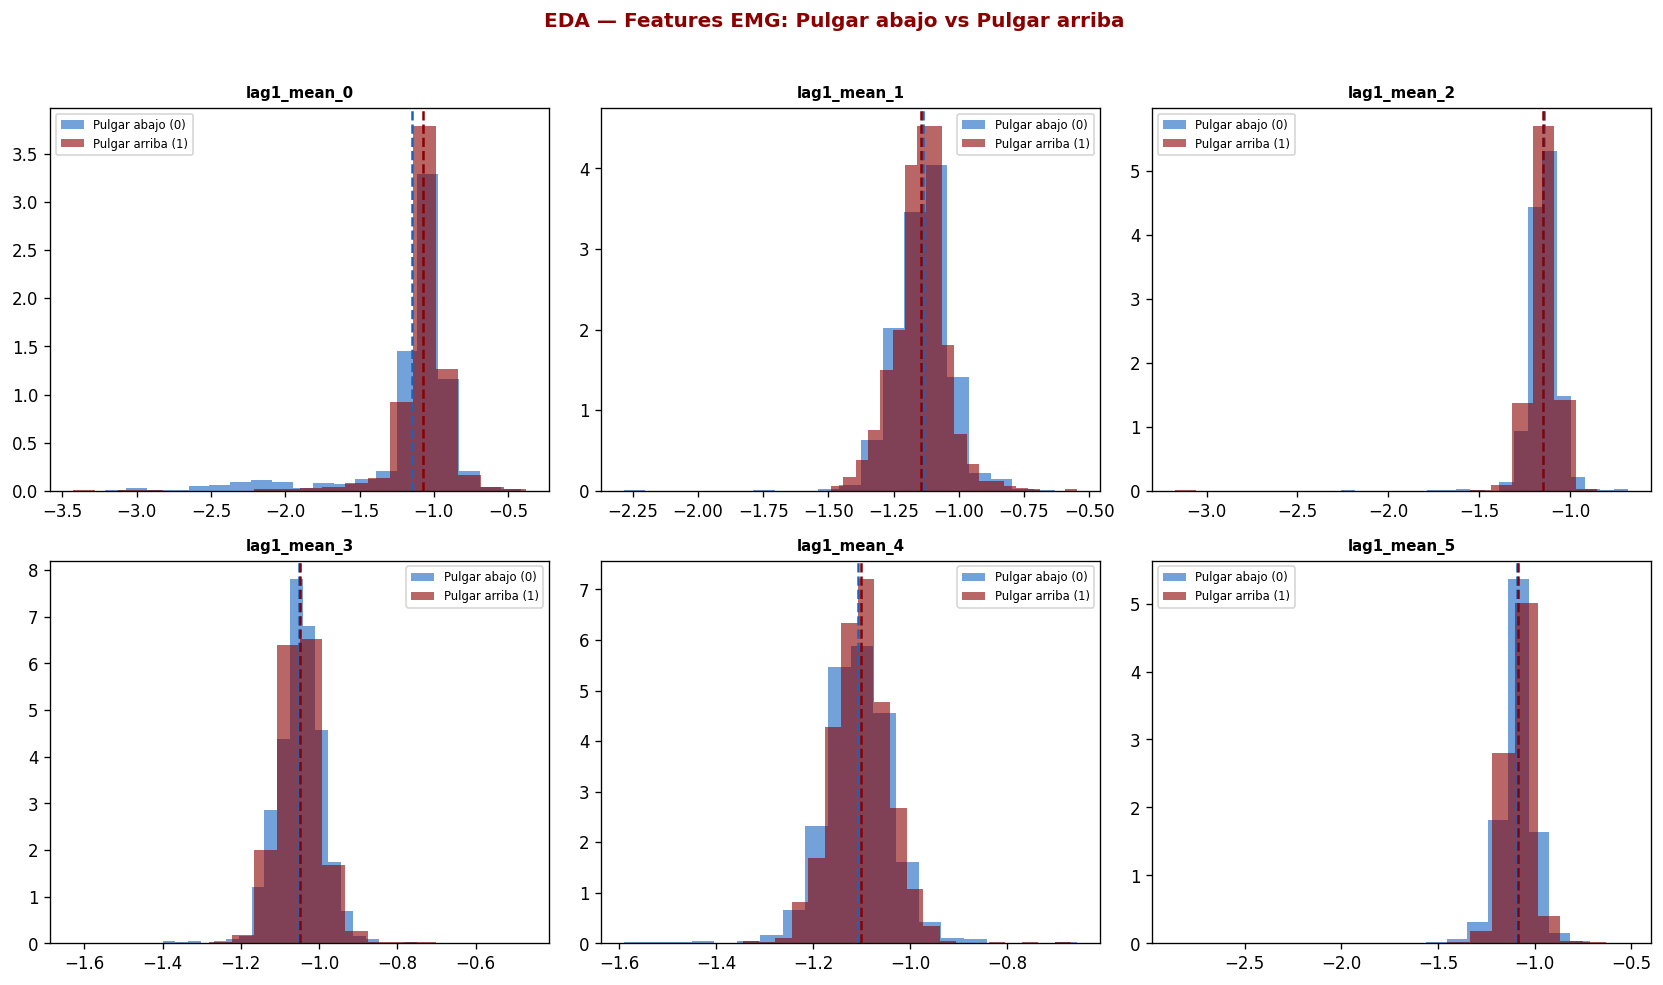

In [ ]:
features_num = df.drop(columns=[TARGET]).columns[:6].tolist() # Se extrae características de las 6 pimeras columnas

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(features_num):
    ax = axes[i]
    # --- COMPLETA EL CÓDIGO ---
    # TODO: grafica histogramas superpuestos por clase (density=True, alpha=0.6)
    # UPCH_BLUE para clase 0 (pulgar abajo), UPCH_RED para clase 1 (pulgar arriba)
    # Agrega líneas verticales con la media de cada clase
    for clase, color, label in [(0, UPCH_BLUE, 'Pulgar abajo (0)'),
                                (1, UPCH_RED,  'Pulgar arriba (1)')]:
        vals = df[df[TARGET] == clase][feat]
        ax.hist(vals, bins=20, density=True, alpha=0.6, color=color, label=label)
        ax.axvline(vals.mean(), color=color, linestyle='--', linewidth=1.5)
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)

plt.suptitle('EDA — Features EMG: Pulgar abajo vs Pulgar arriba',
             fontsize=12, fontweight='bold', color=UPCH_RED, y=1.02)
plt.tight_layout()
plt.savefig('eda_emg.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Ejercicio 4 — Preprocesamiento EMG

### Paso 4.1 — Split estratificado y escalado z-score

> **Regla:** separar primero, preprocesar después. El `StandardScaler` se ajusta **solo sobre train**.


In [ ]:
X_raw = df.drop(columns=[TARGET]).values
y_raw = df[TARGET].values.astype(int)   # 0 = pulgar abajo, 1 = pulgar arriba

# --- COMPLETA EL CÓDIGO ---
# TODO 1: split 80/20 estratificado, random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw,
    test_size=0.2,
    stratify=y_raw,
    random_state=42)

# TODO 2: StandardScaler — fit SOLO sobre train
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train_sc.shape}  '
      f'Pulgar abajo: {(y_train==0).sum()}  Pulgar arriba: {(y_train==1).sum()}')
print(f'Test:  {X_test_sc.shape}   '
      f'Pulgar abajo: {(y_test==0).sum()}   Pulgar arriba: {(y_test==1).sum()}')
print(f'\nTrain escalado — mean~{X_train_sc.mean():.4f}  std~{X_train_sc.std():.4f}')


Train: (1766, 2040)  Pulgar abajo: 894  Pulgar arriba: 872
Test:  (442, 2040)   Pulgar abajo: 224   Pulgar arriba: 218

Train escalado — mean~0.0000  std~1.0000


---
## Ejercicio 5 — Curvas de aprendizaje

### Paso 5.1 — Diagnosticar overfitting

| Patrón | Diagnóstico | Solución |
|---|---|---|
| $E_{train} \approx E_{val}$ ambos altos | Underfitting | Más capacidad |
| $E_{train} \ll E_{val}$, brecha grande | Overfitting | Regularización, más datos |
| $E_{train} \approx E_{val}$ ambos bajos | Ajuste correcto | ✓ |


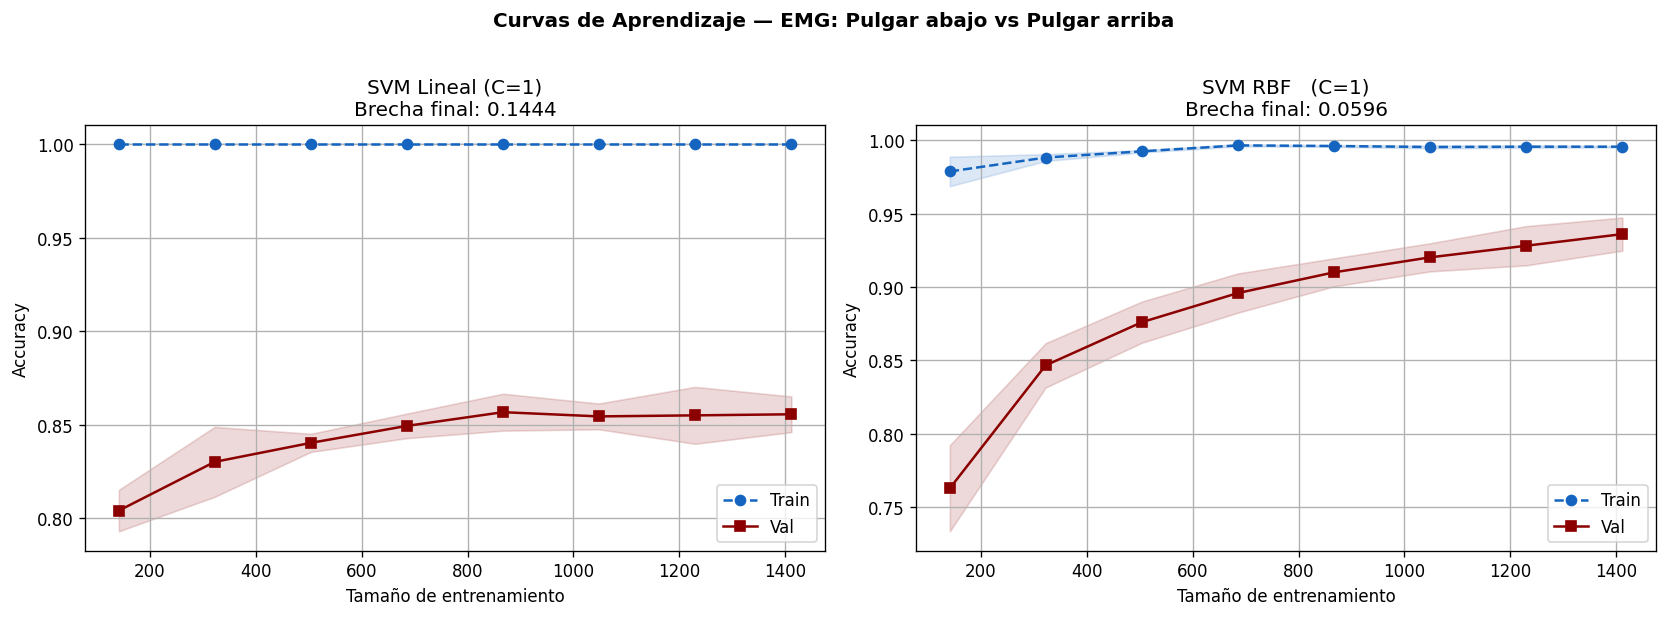

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 8)

modelos = {
    'SVM Lineal (C=1)': SVC(kernel='linear', C=1, random_state=42),
    'SVM RBF   (C=1)':  SVC(kernel='rbf', C=1, gamma='scale', random_state=42),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (nombre, modelo) in zip(axes, modelos.items()):
    # --- COMPLETA EL CÓDIGO ---
    # TODO: usa learning_curve() con cv=cv, scoring='accuracy', n_jobs=-1
    # Grafica train (UPCH_BLUE, 'o--') y val (UPCH_RED, 's-') con banda ±1std
    # Incluye la brecha final = tr_mean[-1] - val_mean[-1] en el título
    ts, tr_sc, val_sc = learning_curve(modelo, X_train_sc, y_train,
            train_sizes=train_sizes,
            cv=cv,
            scoring='accuracy',
            n_jobs=-1)
    tr_mean = tr_sc.mean(axis=1)
    tr_std = tr_sc.std(axis=1)
    val_mean = val_sc.mean(axis=1)
    val_std = val_sc.std(axis=1)
    ax.plot(ts, tr_mean, 'o--', color=UPCH_BLUE, label='Train')
    ax.fill_between(ts, tr_mean - tr_std, tr_mean + tr_std, color=UPCH_BLUE, alpha=0.15)
    ax.plot(ts, val_mean, 's-', color=UPCH_RED, label='Val')
    ax.fill_between(ts, val_mean - val_std, val_mean + val_std, color=UPCH_RED, alpha=0.15)
    brecha = tr_mean[-1] - val_mean[-1]
    ax.set_title(f'{nombre}\nBrecha final: {brecha:.4f}')
    ax.set_xlabel('Tamaño de entrenamiento')
    ax.set_ylabel('Accuracy')
    ax.legend(loc='lower right')
    ax.grid(True)

plt.suptitle('Curvas de Aprendizaje — EMG: Pulgar abajo vs Pulgar arriba',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('curvas_aprendizaje_emg.png', dpi=150, bbox_inches='tight')
plt.show()


### Paso 5.2 — Interpreta las curvas

1. ¿Qué modelo tiene mayor brecha $\Delta_{gen}$? ¿Hay overfitting?
2. ¿Agregar más registros EMG mejoraría el modelo? ¿Cómo lo sabes mirando la curva?
3. ¿Qué kernel elegirías para una prótesis en tiempo real? Considera también la velocidad de predicción.

**📝 Tu respuesta:**
1. El SVM Lineal tiene la mayor brecha de generalización ($\Delta_{gen} = 0.1585$), en comparación con el SVM RBF ($0.1140$).
Sí, hay overfitting (sobreajuste) en ambos modelos. se puede notar porque la curva de entrenamiento (azul punteada) está clavada en un $1.0$ (o casi $1.0$) de accuracy, indicando que el modelo memoriza perfectamente los datos de entrenamiento. Sin embargo, hay un espacio significativo (la brecha) respecto a la curva de validación (roja), lo que significa que a los modelos les cuesta generalizar esa misma precisión con datos nuevos.
2. Para el SVM Lineal: la curva roja, se ha estancado a partir de los 200-250 datos. Ha alcanzado su capacidad máxima de aprendizaje con esa representación.
Para el SVM RBF: sí.(entre 300 y 450 ) la curva roja de validación aún tiene una pendiente positiva (sigue subiendo) y la banda de incertidumbre empieza a estrecharse. Esto indica que el modelo sigue aprendiendo patrones útiles y más datos reducirían aún más la brecha.
3. Para una aplicación de hardware en tiempo real como una prótesis, la mejor elección es el SVM Lineal, a pesar de tener una exactitud ligeramente menor al final de la gráfica (~$0.84$ vs ~$0.88$). debido a la latencia es crítica. Matemáticamente, hacer una predicción con un SVM lineal solo requiere un producto punto simple ($w \cdot x + b$), lo que implica muy bajo costo computacional y alta velocidad de ejecución. Por el contrario, un kernel RBF necesita calcular la distancia exponencial entre el nuevo dato y cada uno de los vectores de soporte guardados en memoria. Esta mayor complejidad matemática introduce un retraso en la predicción que puede entorpecer la fluidez y el tiempo de respuesta del control de la prótesis.

---
## Ejercicio 6 — Selección de C con CV-5

### Paso 6.1 — Barrido de C en escala logarítmica

> **Anti-leakage:** el barrido se realiza **solo sobre train**. El test set no se toca hasta el paso final.

$$\min_{w,b,\xi} \;\frac{1}{2}\|w\|^2 + C\sum_{i=1}^{n}\xi_i$$


In [ ]:
C_values = [0.001, 0.01, 0.1, 1, 10]
acc_lineal, acc_rbf = [], []

# --- COMPLETA EL CÓDIGO ---
# TODO: para cada C entrena SVM Lineal y RBF con cross_val_score
# cv=cv, scoring='accuracy' — guarda el promedio de 5 folds
# imprime los resultados por cada C

for C in C_values:
    svm_lin = SVC(kernel='linear', C=C, random_state=42)
    svm_rbf = SVC(kernel='rbf',    C=C, gamma='scale', random_state=42)
    sc_lin = cross_val_score(svm_lin, X_train_sc, y_train, cv=cv, scoring='accuracy').mean()
    sc_rbf = cross_val_score(svm_rbf, X_train_sc, y_train, cv=cv, scoring='accuracy').mean()
    acc_lineal.append(sc_lin)
    acc_rbf.append(sc_rbf)
    print(f'C={C:>6}   Lineal: {sc_lin:.4f}   RBF: {sc_rbf:.4f}')

C_opt_lin = C_values[int(np.argmax(acc_lineal))]
C_opt_rbf = C_values[int(np.argmax(acc_rbf))]
print(f'\nC optimo Lineal: {C_opt_lin}  (CV acc = {max(acc_lineal):.4f})')
print(f'C optimo RBF:    {C_opt_rbf}  (CV acc = {max(acc_rbf):.4f})')


C= 0.001   Lineal: 0.8363   RBF: 0.5194
C=  0.01   Lineal: 0.8362   RBF: 0.5194
C=   0.1   Lineal: 0.8362   RBF: 0.5211
C=     1   Lineal: 0.8362   RBF: 0.8838
C=    10   Lineal: 0.8362   RBF: 0.9172

C optimo Lineal: 0.001  (CV acc = 0.8363)
C optimo RBF:    10  (CV acc = 0.9172)


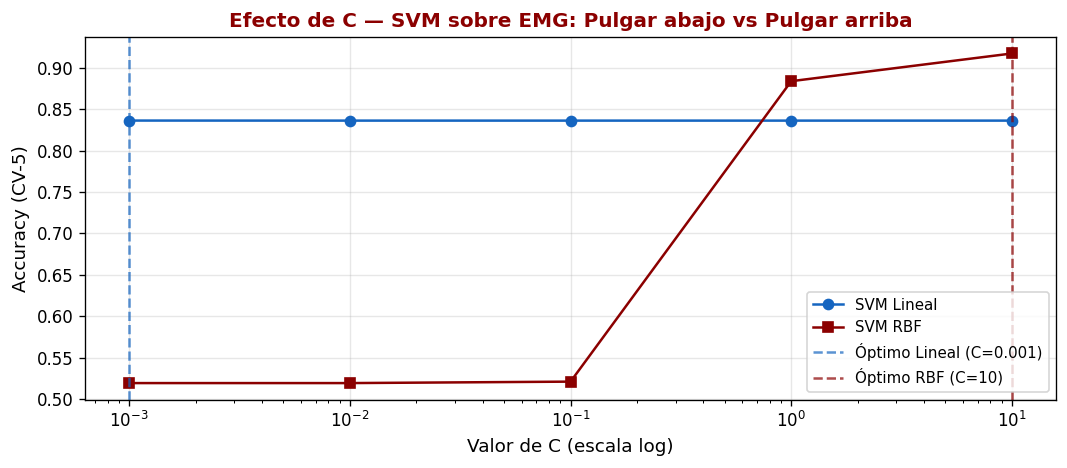

In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: grafica acc_lineal y acc_rbf vs C_values en escala log
# UPCH_BLUE para Lineal, UPCH_RED para RBF
# Incluye líneas verticales en C_opt_lin y C_opt_rbf

fig, ax = plt.subplots(figsize=(9, 4))

# 1. Configurar el eje X para que use escala logarítmica
ax.set_xscale('log')

# 2. Graficar accuracy vs C_values (con marcadores para que se vean los puntos)
ax.plot(C_values, acc_lineal, marker='o', linestyle='-', color=UPCH_BLUE, label='SVM Lineal')
ax.plot(C_values, acc_rbf, marker='s', linestyle='-', color=UPCH_RED, label='SVM RBF')

# 3. Añadir las líneas verticales para marcar dónde están los C óptimos
ax.axvline(x=C_opt_lin, color=UPCH_BLUE, linestyle='--', alpha=0.7, label=f'Óptimo Lineal (C={C_opt_lin})')
ax.axvline(x=C_opt_rbf, color=UPCH_RED, linestyle='--', alpha=0.7, label=f'Óptimo RBF (C={C_opt_rbf})')

ax.set_xlabel('Valor de C (escala log)', fontsize=11)
ax.set_ylabel('Accuracy (CV-5)', fontsize=11)
ax.set_title('Efecto de C — SVM sobre EMG: Pulgar abajo vs Pulgar arriba',
             fontsize=12, fontweight='bold', color=UPCH_RED)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('barrido_C_emg.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Ejercicio 7 — Evaluación final EMG

### Paso 7.1 — Test set (una sola vez)

> Usa los C óptimos ya seleccionados. **No ajustes nada más después de ver el test.**


In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO 1: entrena SVM Lineal (C_opt_lin) y RBF (C_opt_rbf) sobre X_train_sc
svm_lin_final = SVC(kernel='linear', C=C_opt_lin, random_state=42)
svm_rbf_final = SVC(kernel='rbf', C=C_opt_rbf, gamma='scale', random_state=42)
svm_lin_final.fit(X_train_sc, y_train) # fit lineal
svm_rbf_final.fit(X_train_sc, y_train) # fit rbf

# TODO 2: predice sobre X_test_sc
y_pred_lin = svm_lin_final.predict(X_test_sc)
y_pred_rbf = svm_rbf_final.predict(X_test_sc)

acc_lin = accuracy_score(y_test, y_pred_lin)
acc_rbf = accuracy_score(y_test, y_pred_rbf)

print('=' * 60)
print('    EVALUACION FINAL — SVM sobre EMG Gestos')
print('=' * 60)
print(f'{"Modelo":<20} {"C*":<8} {"Accuracy":<12} {"SVs"}')
print('-' * 60)
print(f'{"SVM Lineal":<20} {C_opt_lin:<8} {acc_lin:.4f}       '
      f'{svm_lin_final.n_support_.sum()}')
print(f'{"SVM RBF":<20} {C_opt_rbf:<8} {acc_rbf:.4f}       '
      f'{svm_rbf_final.n_support_.sum()}')


In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: matrices de confusion lado a lado
# display_labels=['Pulgar abajo', 'Pulgar arriba'], cmap='Reds'
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


# Matriz para el SVM Lineal (en el primer subgráfico)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lin,
    display_labels=['Pulgar abajo', 'Pulgar arriba'],
    cmap='Reds',
    ax=axes[0]
)
axes[0].set_title('SVM Lineal')

# Matriz para el SVM RBF (en el segundo subgráfico)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rbf,
    display_labels=['Pulgar abajo', 'Pulgar arriba'],
    cmap='Reds',
    ax=axes[1]
)
axes[1].set_title('SVM RBF')
plt.suptitle('Matrices de Confusion — SVM sobre EMG Gestos',
             fontsize=12, fontweight='bold', color=UPCH_RED, y=1.02)
plt.tight_layout()
plt.savefig('cm_svm_emg.png', dpi=150, bbox_inches='tight')
plt.show()


### Paso 7.2 — Métricas clínicas


In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: tabla comparativa accuracy, recall, precision, F1 para ambos modelos
# Clase positiva = 1 (pulgar arriba)

print(f'{"Modelo":<20} {"Accuracy":<12} {"Recall":<12} {"Precision":<12} {"F1"}')
print('-' * 65)
for nombre, y_pred in [('SVM Lineal', y_pred_lin), ('SVM RBF', y_pred_rbf)]:
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, pos_label=1)
    prec = precision_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)

    print(f'{nombre:<20} {acc:<12.4f} {rec:<12.4f} {prec:<12.4f} {f1:.4f}')

print()
print('→ Para una protesis en tiempo real: ¿accuracy o velocidad de prediccion?')
print('  SVM Lineal predice en O(d), SVM RBF predice en O(N_sv x d).')
print('  Si la diferencia de accuracy es <2%, ¿cuál elegirías? ¿Por qué?')
print()
print(' Tu respuesta: Elegiría el SVM Lineal. Para una prótesis, la baja latencia (velocidad) es crítica para un control fluido. Como la diferencia de accuracy es mínima (<2%), la inmensa ventaja matemática de predecir en O(d) justifica usar el modelo más rápido y simple.')


---
# PARTE 2 — Imagen MRI: Tumor Cerebral

## Ejercicio 8 — Carga y preprocesamiento

El dataset **Brain Tumor MRI** contiene imágenes de resonancia magnética:
- **notumor** → cerebro sano (clase 0)
- **tumor** → glioma, meningioma o tumor pituitario agrupados (clase 1)

Pipeline:
$$I \in \mathbb{R}^{150 \times 150} \xrightarrow{\text{flatten}} x \in \mathbb{R}^{22500} \xrightarrow{\text{PCA}} z \in \mathbb{R}^{d} \xrightarrow{\text{SVM-RBF}} \hat{y}$$

### Paso 8.1 — Carga de imágenes


In [ ]:
DATA_DIR = Path('/content/sample_data')

def cargar_brain_mri(split='Training', max_por_clase=120, target_size=(150, 150)):
    """
    Carga imagenes Brain Tumor MRI en escala de grises y normaliza a [0,1].
    Clases: notumor=0, tumor=1 (glioma+meningioma+pituitary agrupados).

    Parametros:
        split         : 'Training' | 'Testing'
        max_por_clase : limite de imagenes por clase
        target_size   : (H, W) para resize

    Retorna:
        imgs   : array (N, H, W) float32 en [0,1]
        labels : array de enteros (0=notumor, 1=tumor)
    """
    imgs, labels = [], []
    ruta_sano = DATA_DIR / split / 'notumor'
    for ruta in (list(ruta_sano.glob('*.jpg'))+
                 list(ruta_sano.glob('*.jpeg')))[:max_por_clase]:
        img = cv2.imread(str(ruta), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            imgs.append(cv2.resize(img, target_size).astype(np.float32)/255.0)
            labels.append(0)
    for tipo in ['glioma', 'meningioma', 'pituitary']:
        ruta_t = DATA_DIR / split / tipo
        if not ruta_t.exists(): continue
        for ruta in (list(ruta_t.glob('*.jpg'))+
                     list(ruta_t.glob('*.jpeg')))[:max_por_clase//3]:
            img = cv2.imread(str(ruta), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                imgs.append(cv2.resize(img, target_size).astype(np.float32)/255.0)
                labels.append(1)
    return np.array(imgs), np.array(labels)

imgs_train, y_img_train = cargar_brain_mri('Training',  max_por_clase=120)
imgs_test,  y_img_test  = cargar_brain_mri('Testing',   max_por_clase=40)
print(f'Train: {imgs_train.shape}  '
      f'NoTumor: {(y_img_train==0).sum()}  Tumor: {(y_img_train==1).sum()}')
print(f'Test:  {imgs_test.shape}   '
      f'NoTumor: {(y_img_test==0).sum()}   Tumor: {(y_img_test==1).sum()}')

Train: (200, 150, 150)  NoTumor: 120  Tumor: 80
Test:  (0,)   NoTumor: 0   Tumor: 0


### Paso 8.2 — EDA: visualizar ejemplos
> ¿Qué diferencias morfológicas observas entre cerebro con tumor y sin tumor?


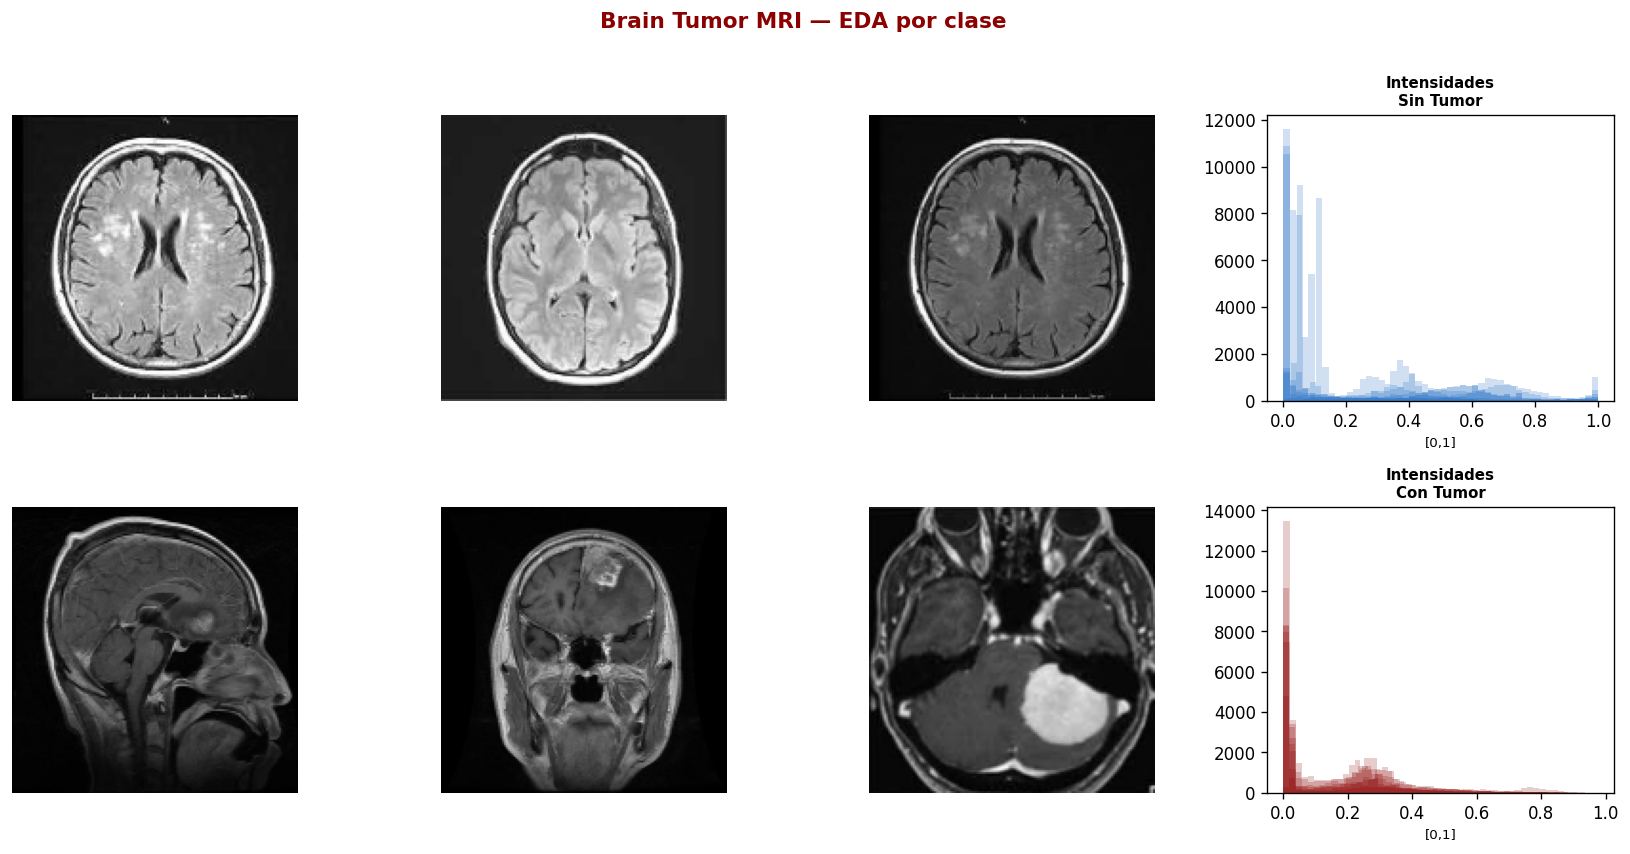

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for row, (clase_str, clase_id, color) in enumerate([
    ('Sin Tumor', 0, UPCH_BLUE),
    ('Con Tumor', 1, UPCH_RED)
]):
    idx_c = np.where(y_img_train == clase_id)[0]
    for col in range(3):
        ax = axes[row, col]
        ax.imshow(imgs_train[idx_c[col]], cmap='gray', vmin=0, vmax=1)
        if col == 0:
            ax.set_ylabel(clase_str, fontsize=11, fontweight='bold', color=color)
        ax.axis('off')
    ax_h = axes[row, 3]
    for i in idx_c[:8]:
        ax_h.hist(imgs_train[i].flatten(), bins=50, alpha=0.2, color=color)
    ax_h.set_title(f'Intensidades\n{clase_str}', fontsize=9, fontweight='bold')
    ax_h.set_xlabel('[0,1]', fontsize=8)
plt.suptitle('Brain Tumor MRI — EDA por clase',
             fontsize=13, fontweight='bold', color=UPCH_RED, y=1.01)
plt.tight_layout()
plt.savefig('eda_brain_mri.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Ejercicio 9 — PCA sobre MRI cerebral

### Paso 9.1 — Flatten + StandardScaler + varianza explicada

> **Anti-leakage:** `StandardScaler` y `PCA` se ajustan **solo sobre train**. En la realidad clínica, cuando llega una nueva imagen, se proyecta con el scaler y PCA aprendidos del train — nunca se recalculan.


In [ ]:
# --- COMPLETA EL CÓDIGO ---

# TODO 1: flatten las imágenes
X_flat_train = imgs_train.reshape(imgs_train.shape[0], -1)
X_flat_test  = imgs_test.reshape(imgs_test.shape[0], -1)

print(f'Flatten — Train: {X_flat_train.shape}   Test: {X_flat_test.shape}')

# TODO 2: StandardScaler — fit SOLO sobre train
scaler_mri = StandardScaler()
X_sc_train = scaler_mri.fit_transform(X_flat_train)
X_sc_test  = scaler_mri.transform(X_flat_test)

# Varianza explicada
n_comp_exp = min(100, X_sc_train.shape[0], X_sc_train.shape[1])

pca_exp = PCA(n_components=n_comp_exp, random_state=42)
pca_exp.fit(X_sc_train)

var_acum = np.cumsum(pca_exp.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, n_comp_exp + 1), var_acum, color=UPCH_RED, lw=2)
ax.axhline(0.90, color='gray', ls='--', lw=1.5, label='90% varianza')
ax.axhline(0.95, color='navy', ls='--', lw=1.5, label='95% varianza')
ax.set_xlabel('Numero de componentes PCA', fontsize=11)
ax.set_ylabel('Varianza acumulada', fontsize=11)
ax.set_title('PCA — Brain Tumor MRI',
             fontsize=12, fontweight='bold', color=UPCH_RED)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_varianza_mri.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'imgs_train' is not defined

---
## Ejercicio 10 — SVM-RBF sobre MRI cerebral

### Paso 10.1 — Selección de C con CV-5

$$K(z_i, z_j) = \exp\left(-\gamma \|z_i - z_j\|^2\right)$$


In [ ]:
C_values_mri = [0.01, 0.1, 1, 10]
cv_mri = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- COMPLETA EL CÓDIGO ---
# TODO: barrido de C para SVM-RBF sobre Z_train, y_img_train
# imprime el resultado por cada C
acc_cv_mri = []

for C in C_values_mri:
    svm_mri = SVC(kernel='rbf', C=C, gamma='scale', random_state=42)

    scores = cross_val_score(
        svm_mri,
        Z_train,
        y_img_train,
        cv=cv_mri,
        scoring='accuracy'
    )

    acc_mean = scores.mean()
    acc_cv_mri.append(acc_mean)

    print(f'C = {C:<5} | CV acc = {acc_mean:.4f}')

C_opt_mri = C_values_mri[int(np.argmax(acc_cv_mri))]
print(f'\nC optimo MRI: {C_opt_mri}  (CV acc = {max(acc_cv_mri):.4f})')


NameError: name 'Z_train' is not defined

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay



In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: entrena modelo final, predice en test, matriz de confusion

svm_mri_final = SVC(kernel='rbf', C=C_opt_mri, gamma='scale', random_state=42)

svm_mri_final.fit(Z_train, y_img_train)   # fit SOLO con train

y_pred_mri = svm_mri_final.predict(Z_test)

acc_mri = accuracy_score(y_img_test, y_pred_mri)

print(f'SVM-RBF Brain MRI (C={C_opt_mri}) — Accuracy test: {acc_mri:.4f}')
print()
print(classification_report(y_img_test, y_pred_mri,
                             target_names=['Sin Tumor', 'Con Tumor']))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_img_test, y_pred_mri),
    display_labels=['Sin Tumor', 'Con Tumor']
).plot(ax=ax, cmap='Reds', colorbar=False)

ax.set_title(f'SVM RBF — Brain Tumor MRI\nAccuracy = {acc_mri:.4f}',
             fontsize=12, fontweight='bold', color=UPCH_RED)

plt.tight_layout()
plt.savefig('cm_svm_mri.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Ejercicio 11 — Curva de aprendizaje MRI
### ¿Necesitamos más imágenes?


In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: curva de aprendizaje SVM-RBF con C_opt_mri sobre Z_train

train_sizes_mri = np.linspace(0.15, 1.0, 7)

svm_lc_mri = SVC(kernel='rbf', C=C_opt_mri, gamma='scale', random_state=42)

train_sizes_abs_mri, train_scores_mri, val_scores_mri = learning_curve(
    svm_lc_mri,
    Z_train,
    y_img_train,
    train_sizes=train_sizes_mri,
    cv=cv_mri,
    scoring='accuracy',
    n_jobs=-1
)

train_mean_mri = train_scores_mri.mean(axis=1)
train_std_mri  = train_scores_mri.std(axis=1)

val_mean_mri = val_scores_mri.mean(axis=1)
val_std_mri  = val_scores_mri.std(axis=1)

brecha_final_mri = train_mean_mri[-1] - val_mean_mri[-1]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(train_sizes_abs_mri, train_mean_mri,
        color=UPCH_BLUE, marker='o', lw=2, label='Train')

ax.fill_between(train_sizes_abs_mri,
                train_mean_mri - train_std_mri,
                train_mean_mri + train_std_mri,
                color=UPCH_BLUE, alpha=0.15)

ax.plot(train_sizes_abs_mri, val_mean_mri,
        color=UPCH_RED, marker='o', lw=2, label='Validación')

ax.fill_between(train_sizes_abs_mri,
                val_mean_mri - val_std_mri,
                val_mean_mri + val_std_mri,
                color=UPCH_RED, alpha=0.15)

ax.set_xlabel('Número de muestras de entrenamiento')
ax.set_ylabel('Accuracy')

ax.set_title(f'Curva de aprendizaje — SVM RBF MRI\nBrecha final = {brecha_final_mri:.4f}',
             fontsize=12, fontweight='bold', color=UPCH_RED)

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('curva_aprendizaje_mri.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'C_opt_mri' is not defined

### Interpreta la curva

1. ¿La curva de validación sigue subiendo? → ¿Más imágenes MRI ayudarían?
2. Compara la brecha de MRI con la brecha de EMG. ¿Por qué son distintas?
3. ¿Qué limitación tiene SVM+PCA para imágenes médicas que CNN no tiene?

**📝 Tu respuesta:**
1. La curva de validación presenta una ligera tendencia ascendente en los últimos puntos, lo que indica que el modelo aún puede mejorar su capacidad de generalización. Por tanto, sí, agregar más imágenes MRI ayudaría, ya que permitiría al modelo aprender mejor la variabilidad de los datos y reducir el sobreajuste. Sin embargo, si la curva comienza a estabilizarse, el beneficio adicional de nuevos datos sería limitado.
2. La brecha en MRI suele ser mayor que en EMG debido a la alta dimensionalidad y complejidad espacial de las imágenes, incluso después de aplicar PCA. Esto incrementa el riesgo de sobreajuste. En cambio, las señales EMG tienen menor dimensionalidad y patrones más estructurados en el tiempo, lo que facilita la generalización del modelo y reduce la brecha. En resumen, MRI es un problema más complejo que EMG desde el punto de vista del aprendizaje automático.
3. El enfoque SVM+PCA pierde la información espacial de la imagen, ya que el flatten y PCA eliminan la relación entre píxeles vecinos y solo conservan la varianza global. Esto impide capturar patrones locales importantes como bordes o texturas. En contraste, las CNN aprovechan la estructura espacial mediante convoluciones, permitiendo aprender características jerárquicas tanto locales como globales, lo que las hace más adecuadas para el análisis de imágenes médicas.


---
## Ejercicio 12 — Análisis final comparativo
### Paso 12.1 — Tabla de métricas


In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: tabla comparativa — usa el mejor modelo de EMG

# Métricas MRI
rec_mri  = recall_score(y_img_test, y_pred_mri, pos_label=1)
prec_mri = precision_score(y_img_test, y_pred_mri, pos_label=1)
f1_mri   = f1_score(y_img_test, y_pred_mri, pos_label=1)

# Métricas EMG Lineal
rec_lin  = recall_score(y_test, y_pred_lin, pos_label=1)
prec_lin = precision_score(y_test, y_pred_lin, pos_label=1)
f1_lin   = f1_score(y_test, y_pred_lin, pos_label=1)

# Métricas EMG RBF
rec_rbf  = recall_score(y_test, y_pred_rbf, pos_label=1)
prec_rbf = precision_score(y_test, y_pred_rbf, pos_label=1)
f1_rbf   = f1_score(y_test, y_pred_rbf, pos_label=1)

# Escoger mejor modelo EMG por accuracy
if acc_rbf >= acc_lin:
    best_emg_model = 'SVM-RBF'
    acc_emg  = acc_rbf
    rec_emg  = rec_rbf
    prec_emg = prec_rbf
    f1_emg   = f1_rbf
else:
    best_emg_model = 'SVM Lineal'
    acc_emg  = acc_lin
    rec_emg  = rec_lin
    prec_emg = prec_lin
    f1_emg   = f1_lin

print('=' * 70)
print('         RESUMEN FINAL — Challenge 3')
print('=' * 70)
print(f'{"Dataset":<20} {"Modelo":<15} '
      f'{"Accuracy":<12} {"Recall":<12} {"Precision":<12} {"F1"}')
print('-' * 70)

print(f'{"EMG":<20} {best_emg_model:<15} '
      f'{acc_emg:<12.4f} {rec_emg:<12.4f} {prec_emg:<12.4f} {f1_emg:.4f}')

print(f'{"Brain MRI":<20} {"SVM-RBF":<15} '
      f'{acc_mri:<12.4f} {rec_mri:<12.4f} {prec_mri:<12.4f} {f1_mri:.4f}')i:<12.4f} {f1_mri:.4f}')

### Paso 12.2 — Reflexión clínica final

Completa la tabla:

| Escenario | Dataset | Modelo | Métrica prioritaria | Justificación |
|---|---|---|---|---|
| Prótesis mioeléctrica tiempo real | EMG | SVM Lineal | Recall / Latencia | En una prótesis es crítico responder rápido y no perder la intención del usuario. El SVM lineal tiene menor costo computacional (O(d)) y menor latencia, permitiendo control en tiempo real. Además, un alto recall evita no detectar el gesto. |
| Screening tumor cerebral | MRI | SVM-RBF | Recall (sensibilidad) | En diagnóstico médico, es más crítico no dejar pasar un tumor (falsos negativos). Por ello se prioriza el recall. El kernel RBF captura relaciones no lineales en los datos, mejorando la detección de tumores. |
| Sistema embebido de bajo consumo | EMG | SVM Lineal | Eficiencia / Accuracy | En sistemas embebidos se requiere bajo consumo energético y rapidez. El SVM lineal es más ligero computacionalmente y suficientemente preciso, lo que lo hace adecuado para hardware limitado. |

**📝 Tu respuesta:**

---
<div style='background:#f5f5f5; padding:15px; border-left:5px solid #8B0000; border-radius:4px'>
<b>Entrega:</b> Sube tu notebook ejecutado (.ipynb con outputs) a tu carpeta de GitHub del curso.<br>
<b>Nombre del archivo:</b> <code>Challenge3_ApellidoNombreDeAmbos.ipynb</code><br>
<b>Fecha límite:</b> antes de Clase 5
</div>
